Contextualizacion

El análisis de este dataset es altamente relevante para una empresa de juegos de azar online, ya que permite comprender el comportamiento de los usuarios, sus patrones de apuesta y frecuencia de juego. Esta información es clave para optimizar estrategias de retención de clientes, personalizar ofertas y detectar posibles comportamientos anómalos o fraudulentos. Además, facilita la toma de decisiones basada en datos para maximizar ingresos y mejorar la experiencia del usuario.

## Definición del problema y objetivo del análisis (CRISP-DM)

**Fase 1 - Comprensión del negocio**
El objetivo es analizar un dataset de juegos de casino online para identificar patrones que ayuden a mejorar la retención de usuarios, optimizar decisiones comerciales y preparar una base sólida para modelado predictivo.

**Fase 2 - Comprensión de los datos**
Revisaremos estructura, tipos de variables, calidad de datos, valores faltantes y relaciones entre variables.

**Fase 3 - Preparación de los datos**
Aplicaremos limpieza, imputación, transformación de variables categóricas y escalado de variables numéricas.

**Resultado esperado**
Obtener un dataset consistente y analíticamente útil, acompañado de interpretaciones claras en lenguaje natural.

### Justificación del bloque de carga e inspección inicial

**Qué se hará:** importar librerías y cargar el archivo CSV en un DataFrame.

**Por qué se hace:** sin esta etapa no podemos validar estructura, tipos de datos ni calidad inicial de la información.

**Qué se espera encontrar:** un DataFrame con columnas coherentes y suficiente calidad para continuar con el análisis exploratorio.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/online_casino_games_dataset_v2.csv')
df.head()


,casino,game,provider,rtp,volatility,jackpot,country_availability,min_bet,max_win,game_type,game_category,license_jurisdiction,release_year,currency,mobile_compatible,free_spins_feature,bonus_buy_available,max_multiplier,languages,last_updated
0,Guts Casino,Texas Hold'em Bonus,Saucify,98.83,Medium,NaN,AR|BR|CH|CO|CY|DE|EE|ES|IE|IL|KE|MT|NZ|PE|PT|R...,1.00,435957.16,poker,Video Poker,MGA,2021,SEK|USD,True,False,False,356.0,EN|ES|TR|IT|JA|DE|FR|CS,2024-09-20
1,Expekt,Mines,Playtech,98.05,Low,NaN,BG|HR|ID|LT|NO|PH|SE|TR,0.25,1396.15,crash,Crash,Curaçao,2018,NZD|BRL|CAD|SEK|AUD,True,False,False,206.0,EN|SV|TR|ZH|PT|ES|FR|JA,2024-02-03
2,Betinia,Mega Vault,Gamomat,95.43,Very High,NaN,CH|ES|GB|HU|ID|IE|IN|LT|NO|SE|SG|VN,0.10,1180.12,slot,3D Slot,Isle of Man,2014,NZD|AUD|BRL|GBP|CAD,True,True,False,1787.0,EN|DE|FI|HU|PT|ZH|FR|JA,2024-07-09
3,Pinnacle,Casino Hold'em Pro,4ThePlayer,99.50,Medium,NaN,BE|BR|MY|NG|PL,0.05,236507.50,poker,Three Card Poker,MGA,2023,DKK|NZD|SEK,True,False,False,369.0,EN|ES|SV|DA|CS|FR|ZH|FI|NO|PT|HU|KO,2024-06-27
4,Winnerz,Solar Star Xtreme,Hacksaw Gaming,97.18,High,NaN,CL|KE|PT|SG|SI,0.20,1093.45,slot,Jackpot Slot,MGA,2022,NOK|GBP,True,True,False,1970.0,EN|JA|PT|KO|ES,2024-04-24


El código anterior importa las librerías `pandas` para manipulación de datos, `numpy` para operaciones numéricas y `matplotlib.pyplot` para visualización. Luego, carga el dataset desde el archivo CSV `online_casino_games_dataset_v2.csv` en un DataFrame llamado `df` y muestra las primeras 5 filas para una vista previa rápida de los datos.

### Justificación: revisión estructural del dataset (`df.info()`)

**Qué se hará:** inspeccionar cantidad de filas, tipos de datos y valores no nulos por columna.

**Por qué se hace:** esta revisión permite detectar problemas tempranos de calidad (tipos incorrectos, posibles faltantes y columnas problemáticas).

**Qué se espera encontrar:** una estructura coherente con el diccionario de datos para pasar al análisis descriptivo.

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   casino                1200000 non-null  object 
 1   game                  1200000 non-null  object 
 2   provider              1200000 non-null  object 
 3   rtp                   1200000 non-null  float64
 4   volatility            1200000 non-null  object 
 5   jackpot               128457 non-null   object 
 6   country_availability  1200000 non-null  object 
 7   min_bet               1200000 non-null  float64
 8   max_win               1200000 non-null  float64
 9   game_type             1200000 non-null  object 
 10  game_category         1200000 non-null  object 
 11  license_jurisdiction  1200000 non-null  object 
 12  release_year          1200000 non-null  int64  
 13  currency              1200000 non-null  object 
 14  mobile_compatible     1200000 non-

Esta celda muestra un resumen conciso del DataFrame `df`, incluyendo el número de entradas, la cantidad de valores no nulos por columna, el tipo de dato (`Dtype`) de cada columna y el uso de memoria. Esto es útil para identificar columnas con valores faltantes y verificar los tipos de datos.

In [ ]:
df.columns

Index(['casino', 'game', 'provider', 'rtp', 'volatility', 'jackpot',
       'country_availability', 'min_bet', 'max_win', 'game_type',
       'game_category', 'license_jurisdiction', 'release_year', 'currency',
       'mobile_compatible', 'free_spins_feature', 'bonus_buy_available',
       'max_multiplier', 'languages', 'last_updated'],
      dtype='object')

La ejecución de `df.columns` devuelve un índice con los nombres de todas las columnas presentes en el DataFrame, lo cual es útil para verificar los nombres exactos de las columnas para futuras operaciones.

### Justificación: validación de nombres de columnas

**Qué se hará:** revisar el listado de columnas exactas del DataFrame.

**Por qué se hace:** evita errores en pasos posteriores (imputación, transformación, modelado) al usar nombres correctos.

**Qué se espera encontrar:** columnas alineadas con el diccionario de datos y listas para su clasificación analítica.

In [ ]:
# Mapeo de datos: columna original -> significado, traducción y clasificación
diccionario_columnas = {
    "casino": {
        "nombre_es": "casino",
        "descripcion": "Nombre del casino donde está disponible el juego",
        "tipo_general": "Categórica",
        "subtipo": "Nominal"
    },
    "game": {
        "nombre_es": "juego",
        "descripcion": "Nombre del juego",
        "tipo_general": "Categórica",
        "subtipo": "Nominal"
    },
    "provider": {
        "nombre_es": "proveedor",
        "descripcion": "Proveedor o desarrollador del juego",
        "tipo_general": "Categórica",
        "subtipo": "Nominal"
    },
    "rtp": {
        "nombre_es": "retorno_al_jugador",
        "descripcion": "Porcentaje de retorno esperado para el jugador",
        "tipo_general": "Numérica",
        "subtipo": "Continua"
    },
    "volatility": {
        "nombre_es": "volatilidad",
        "descripcion": "Nivel de volatilidad del juego",
        "tipo_general": "Categórica",
        "subtipo": "Ordinal"
    },
    "jackpot": {
        "nombre_es": "tiene_jackpot",
        "descripcion": "Indica si el juego incluye jackpot",
        "tipo_general": "Categórica",
        "subtipo": "Binaria"
    },
    "country_availability": {
        "nombre_es": "paises_disponibles",
        "descripcion": "Países donde el juego está habilitado",
        "tipo_general": "Categórica",
        "subtipo": "Nominal"
    },
    "min_bet": {
        "nombre_es": "apuesta_minima",
        "descripcion": "Monto mínimo permitido para apostar",
        "tipo_general": "Numérica",
        "subtipo": "Continua"
    },
    "max_win": {
        "nombre_es": "ganancia_maxima",
        "descripcion": "Ganancia máxima potencial",
        "tipo_general": "Numérica",
        "subtipo": "Continua"
    },
    "game_type": {
        "nombre_es": "tipo_juego",
        "descripcion": "Tipo general del juego (slot, mesa, etc.)",
        "tipo_general": "Categórica",
        "subtipo": "Nominal"
    },
    "game_category": {
        "nombre_es": "categoria_juego",
        "descripcion": "Categoría específica del juego",
        "tipo_general": "Categórica",
        "subtipo": "Nominal"
    },
    "license_jurisdiction": {
        "nombre_es": "jurisdiccion_licencia",
        "descripcion": "Jurisdicción regulatoria de la licencia",
        "tipo_general": "Categórica",
        "subtipo": "Nominal"
    },
    "release_year": {
        "nombre_es": "anio_lanzamiento",
        "descripcion": "Año de lanzamiento del juego",
        "tipo_general": "Numérica",
        "subtipo": "Discreta"
    },
    "currency": {
        "nombre_es": "moneda",
        "descripcion": "Moneda principal del juego",
        "tipo_general": "Categórica",
        "subtipo": "Nominal"
    },
    "mobile_compatible": {
        "nombre_es": "compatible_movil",
        "descripcion": "Compatibilidad con dispositivos móviles",
        "tipo_general": "Categórica",
        "subtipo": "Binaria"
    },
    "free_spins_feature": {
        "nombre_es": "tiene_tiros_gratis",
        "descripcion": "Indica si tiene función de free spins",
        "tipo_general": "Categórica",
        "subtipo": "Binaria"
    },
    "bonus_buy_available": {
        "nombre_es": "compra_bonus_disponible",
        "descripcion": "Permite comprar bono directamente",
        "tipo_general": "Categórica",
        "subtipo": "Binaria"
    },
    "max_multiplier": {
        "nombre_es": "multiplicador_maximo",
        "descripcion": "Máximo multiplicador de ganancia",
        "tipo_general": "Numérica",
        "subtipo": "Discreta"
    },
    "languages": {
        "nombre_es": "idiomas",
        "descripcion": "Idiomas disponibles para el juego",
        "tipo_general": "Categórica",
        "subtipo": "Nominal"
    },
    "last_updated": {
        "nombre_es": "fecha_actualizacion",
        "descripcion": "Fecha de última actualización registrada",
        "tipo_general": "Temporal",
        "subtipo": "Fecha"
    }
}

filas_diccionario = []
for columna, meta in diccionario_columnas.items():
    filas_diccionario.append({
        "Columna original": columna,
        "Nombre en español": meta["nombre_es"],
        "Descripción": meta["descripcion"],
        "Tipo general": meta["tipo_general"],
        "Subtipo": meta["subtipo"],
        "Tipo de dato en pandas": str(df[columna].dtype) if columna in df.columns else "No encontrada",
        "Existe en dataset": columna in df.columns
    })

descripcion_columnas = pd.DataFrame(filas_diccionario)
descripcion_columnas

,Columna original,Nombre en español,Descripción,Tipo general,Subtipo,Tipo de dato en pandas,Existe en dataset
0,casino,casino,Nombre del casino donde está disponible el juego,Categórica,Nominal,object,True
1,game,juego,Nombre del juego,Categórica,Nominal,object,True
2,provider,proveedor,Proveedor o desarrollador del juego,Categórica,Nominal,object,True
3,rtp,retorno_al_jugador,Porcentaje de retorno esperado para el jugador,Numérica,Continua,float64,True
4,volatility,volatilidad,Nivel de volatilidad del juego,Categórica,Ordinal,object,True
5,jackpot,tiene_jackpot,Indica si el juego incluye jackpot,Categórica,Binaria,object,True
6,country_availability,paises_disponibles,Países donde el juego está habilitado,Categórica,Nominal,object,True
7,min_bet,apuesta_minima,Monto mínimo permitido para apostar,Numérica,Continua,float64,True
8,max_win,ganancia_maxima,Ganancia máxima potencial,Numérica,Continua,float64,True
9,game_type,tipo_juego,"Tipo general del juego (slot, mesa, etc.)",Categórica,Nominal,object,True


### Interpretación del mapeo y clasificación de variables

Con este diccionario de datos se cumple el **mapeo de columnas** solicitado: cada variable quedó traducida a un nombre analítico en español y acompañada por su significado.

Además, se dejó explícita la **clasificación estadística** de cada variable (numérica/categórica, continua/discreta, nominal/ordinal/binaria), lo que facilita decidir tratamientos de preprocesamiento:
- Las variables numéricas continuas (por ejemplo, `rtp`, `min_bet`, `max_win`) son candidatas a escalado y análisis de dispersión.
- Las variables categóricas nominales requieren codificación para modelos.
- Las variables ordinales conservan un orden lógico y deben tratarse respetando esa jerarquía.
- Las variables binarias pueden interpretarse como indicadores 0/1.

Este bloque aporta trazabilidad metodológica y mejora la interpretación del análisis posterior.

### Justificación: estadísticas descriptivas iniciales

**Qué se hará:** calcular estadísticas globales de variables numéricas (`df.describe()`).

**Por qué se hace:** permite conocer escala, tendencia central y variabilidad antes de decidir transformaciones.

**Qué se espera encontrar:** posibles asimetrías, rangos amplios y señales tempranas de outliers.

In [ ]:
# Variables numéricas
df.describe()


,rtp,min_bet,max_win,release_year,max_multiplier
count,1.200000e+06,1.200000e+06,1.200000e+06,1.200000e+06,986186.000000
mean,9.620959e+01,4.697106e-01,3.366431e+05,2.017532e+03,6139.578754
std,2.603477e+00,8.183907e-01,6.698539e+05,4.182238e+00,11375.900548
min,8.500000e+01,1.000000e-02,1.000000e+02,2.010000e+03,10.000000
25%,9.502000e+01,1.000000e-01,2.056287e+03,2.014000e+03,283.000000
50%,9.665000e+01,2.000000e-01,1.589124e+04,2.018000e+03,749.000000
75%,9.809000e+01,5.000000e-01,3.614495e+05,2.021000e+03,6094.000000
max,9.950000e+01,5.000000e+00,4.999956e+06,2.024000e+03,50000.000000


La función `df.describe()` genera estadísticas descriptivas de las columnas numéricas del DataFrame, como la cuenta de valores no nulos, la media, la desviación estándar, el valor mínimo, los cuartiles (25%, 50%, 75%) y el valor máximo. Esto ayuda a comprender la distribución y la variabilidad de las variables numéricas.

In [ ]:
# Media
df.mean(numeric_only=True)

# Mediana
df.median(numeric_only=True)

# Moda (incluye categóricas)
df.mode().iloc[0]


,0
casino,22bet
game,Bonus Poker
provider,NYX Gaming
rtp,99.5
volatility,Medium
jackpot,Local
country_availability,AE|AR|AT|AU|BE|BG|BR|CA|CH|CL|CO|CY|CZ|DE|DK|E...
min_bet,1.0
max_win,1756.19
game_type,slot


Aquí se calcularon las medidas de tendencia central: la media, la mediana y la moda.
*   La **media** (`df.mean()`) es el promedio de los valores numéricos.
*   La **mediana** (`df.median()`) es el valor central cuando los datos están ordenados.
*   La **moda** (`df.mode()`) es el valor que aparece con mayor frecuencia en cada columna, útil tanto para datos numéricos como categóricos. Estos valores proporcionan una visión del centro de la distribución de los datos.

### Justificación: medidas de tendencia central

**Qué se hará:** calcular media, mediana y moda para resumir el centro de la distribución.

**Por qué se hace:** comparar estas medidas ayuda a detectar sesgo y diferencias entre variables numéricas y categóricas.

**Qué se espera encontrar:** variables donde media y mediana difieran, indicando posible asimetría o influencia de valores extremos.

In [ ]:
# Seleccionar solo numéricas reales (excluye booleanos)
df_numeric = df.select_dtypes(include=[np.number])

# Desviación estándar
df_numeric.std()

# IQR
Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)
IQR = Q3 - Q1

IQR


,0
rtp,3.07
min_bet,0.40
max_win,359393.23
release_year,7.00
max_multiplier,5811.00


En esta celda, se calculó la desviación estándar (`df_numeric.std()`) para las columnas numéricas reales (excluyendo booleanos), lo que indica la dispersión de los datos alrededor de la media. Además, se calculó el Rango Intercuartílico (IQR) restando el primer cuartil (Q1) del tercer cuartil (Q3), lo cual es una medida robusta de la dispersión de los datos y es menos sensible a valores atípicos que la desviación estándar.

### Justificación: evaluación de dispersión y outliers

**Qué se hará:** analizar variabilidad con desviación estándar, IQR y boxplots en variables numéricas clave.

**Por qué se hace:** la dispersión condiciona decisiones de limpieza, transformación y robustez de los modelos.

**Qué se espera encontrar:** presencia de valores atípicos en variables monetarias como `max_win` y `min_bet`.

Esta celda prepara un gráfico de caja (boxplot) para visualizar la distribución y detectar valores atípicos en las variables numéricas clave: `min_bet` (apuesta mínima), `max_win` (ganancia máxima) y `rtp` (Return to Player). Los boxplots son útiles para identificar rápidamente la presencia de outliers y la simetría de la distribución.

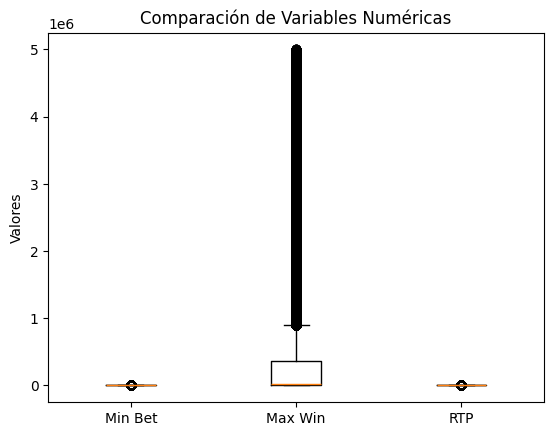

In [ ]:
plt.boxplot([df['min_bet'], df['max_win'], df['rtp']])
plt.title('Comparación de Variables Numéricas')
plt.xticks([1, 2, 3], ['Min Bet', 'Max Win', 'RTP'])
plt.ylabel('Valores')
plt.show()


A través del boxplot se identificaron valores atípicos en variables como la ganancia máxima (max_win) y la apuesta mínima (min_bet), lo que sugiere la existencia de juegos con características extremas. Estos outliers pueden influir en el análisis y deberán ser considerados en etapas posteriores.

In [ ]:
df.isnull().sum()

,0
casino,0
game,0
provider,0
rtp,0
volatility,0
jackpot,1071543
country_availability,0
min_bet,0
max_win,0
game_type,0


### Justificación: detección de valores nulos

**Qué se hará:** contabilizar valores faltantes por columna.

**Por qué se hace:** los nulos pueden sesgar métricas y afectar el entrenamiento de modelos.

**Qué se espera encontrar:** columnas con faltantes que requieran estrategia de imputación diferenciada por tipo de variable.

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns
bool_cols = df.select_dtypes(include=['bool']).columns

### Justificación: segmentación por tipo de variable

**Qué se hará:** separar columnas numéricas, categóricas y booleanas.

**Por qué se hace:** cada tipo requiere un tratamiento distinto en imputación y codificación.

**Qué se espera encontrar:** una estructura que permita aplicar reglas de limpieza consistentes y trazables.

In [ ]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    moda = df[col].mode(dropna=True)
    if not moda.empty:
        df[col] = df[col].fillna(moda.iloc[0])

for col in bool_cols:
    df[col] = df[col].fillna(False)

### Interpretación de la imputación aplicada

Se aplicó una estrategia diferenciada y metodológicamente consistente:

- **Numéricas -> mediana**: reduce el impacto de outliers y preserva el comportamiento central.
- **Categóricas -> moda**: conserva la categoría más representativa del conjunto.
- **Booleanas -> False**: criterio conservador cuando no hay evidencia positiva.

Esta decisión mejora la completitud del dataset sin distorsionar de forma fuerte la distribución de las variables.

In [ ]:
# 1. Eliminar columnas problemáticas (alta cardinalidad)
df = df.drop(columns=[
    'game',
    'languages',
    'country_availability',
    'provider'
], errors='ignore')

# 2. Seleccionar columnas categóricas actualizadas
cat_cols = df.select_dtypes(include=['object']).columns

# 3. Filtrar solo columnas con pocas categorías (evita exceso de RAM)
cat_cols_reducidas = [col for col in cat_cols if df[col].nunique() < 10]

# 4. Aplicar One-Hot Encoding solo a esas columnas
df_encoded = pd.get_dummies(df, columns=cat_cols_reducidas, drop_first=True)

# Ver resultado
print(df_encoded.shape)



(1200000, 29)


### Interpretación del encoding aplicado

Se aplicó **One-Hot Encoding** para convertir variables categóricas en formato numérico utilizable por algoritmos de machine learning.

Para evitar explosión de dimensionalidad, se filtraron columnas con alta cardinalidad y se conservaron variables categóricas con pocas categorías. Esto equilibra dos objetivos:

- mantener información relevante para el modelo,
- preservar eficiencia computacional en memoria y tiempo de entrenamiento.

Además, `drop_first=True` ayuda a reducir redundancia entre variables codificadas.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])


### Justificación e interpretación del escalado

**Qué se hizo:** se estandarizaron variables numéricas con `StandardScaler` para que queden en media 0 y desviación estándar 1.

**Por qué se hizo:** evita que variables en escalas grandes dominen el entrenamiento y mejora convergencia en modelos lineales.

**Interpretación:** tras escalar, las variables son comparables entre sí en términos de magnitud relativa, lo que favorece un aprendizaje más estable.

In [ ]:
df_final = df_encoded.copy()

df_final.head()

,casino,rtp,min_bet,max_win,game_category,release_year,currency,mobile_compatible,free_spins_feature,bonus_buy_available,...,game_type_poker,game_type_scratch,game_type_slot,game_type_table,license_jurisdiction_Curaçao,license_jurisdiction_Gibraltar,license_jurisdiction_Isle of Man,license_jurisdiction_Kahnawake,license_jurisdiction_MGA,license_jurisdiction_UKGC
0,Guts Casino,1.006504,0.647966,0.148262,Video Poker,0.829314,SEK|USD,True,False,False,...,True,False,False,False,False,False,False,False,True,False
1,Expekt,0.706904,-0.268467,-0.500478,Crash,0.111994,NZD|BRL|CAD|SEK|AUD,True,False,False,...,False,False,False,False,True,False,False,False,False,False
2,Betinia,-0.299443,-0.451753,-0.500800,3D Slot,-0.844432,NZD|AUD|BRL|GBP|CAD,True,True,False,...,False,False,True,False,False,False,True,False,False,False
3,Pinnacle,1.263852,-0.512849,-0.149489,Three Card Poker,1.307527,DKK|NZD|SEK,True,False,False,...,True,False,False,False,False,False,False,False,True,False
4,Winnerz,0.372735,-0.329562,-0.500930,Jackpot Slot,1.068420,NOK|GBP,True,True,False,...,False,False,True,False,False,False,False,False,True,False


Finalmente, se obtuvo un dataset limpio, sin valores faltantes, completamente numérico y escalado, listo para ser utilizado en modelos predictivos. Este dataset garantiza consistencia y calidad en las etapas posteriores del análisis.

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 29 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   casino                            1200000 non-null  object 
 1   rtp                               1200000 non-null  float64
 2   min_bet                           1200000 non-null  float64
 3   max_win                           1200000 non-null  float64
 4   game_category                     1200000 non-null  object 
 5   release_year                      1200000 non-null  float64
 6   currency                          1200000 non-null  object 
 7   mobile_compatible                 1200000 non-null  bool   
 8   free_spins_feature                1200000 non-null  bool   
 9   bonus_buy_available               1200000 non-null  bool   
 10  max_multiplier                    1200000 non-null  float64
 11  last_updated                      120

### Justificación: verificación del dataset final preparado

**Qué se hará:** validar estructura y tipos del dataset luego de limpieza, codificación y escalado.

**Por qué se hace:** confirma que los datos están listos para análisis relacional y modelado.

**Qué se espera encontrar:** un conjunto sin nulos, mayoritariamente numérico y consistente para siguientes etapas.

## Análisis de correlación (requisito del curso)

**Qué se hará:** calcular una matriz de correlación entre variables numéricas y visualizarla con un heatmap.

**Por qué se hace:** la correlación permite identificar relaciones lineales fuertes, redundancias y posibles variables influyentes para modelado.

**Qué se espera encontrar:** pares de variables con correlación positiva o negativa relevante, útiles para interpretar comportamiento del negocio.

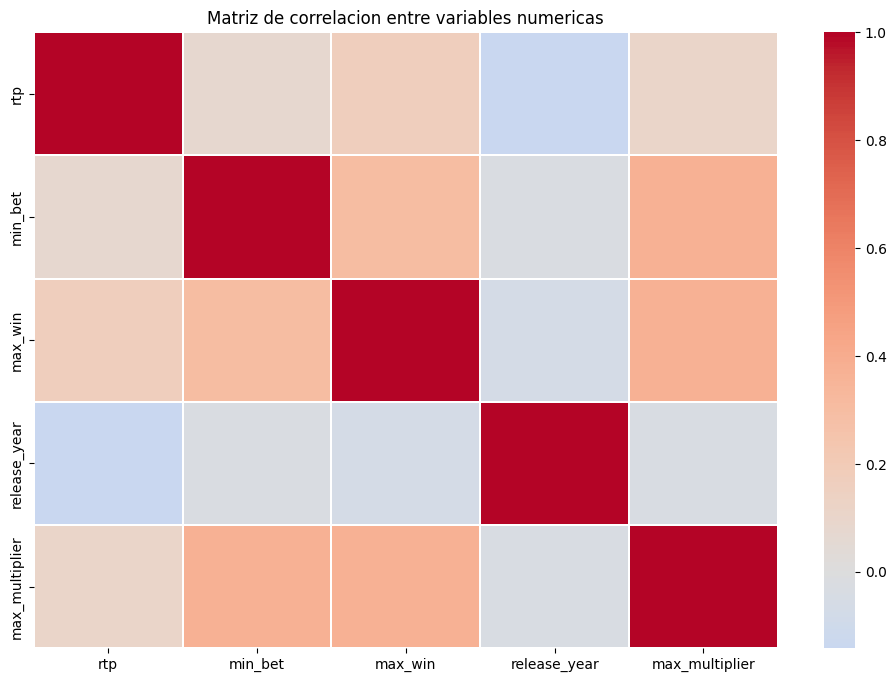

Top 10 pares con mayor correlacion absoluta:
max_win       max_multiplier    0.375643
min_bet       max_multiplier    0.368998
              max_win           0.298991
rtp           max_win           0.173666
              release_year     -0.141553
              max_multiplier    0.106641
              min_bet           0.074802
max_win       release_year     -0.063882
release_year  max_multiplier   -0.036768
min_bet       release_year     -0.025459
dtype: float64

Interpretacion automatica: la relacion mas debil es entre 'max_win' y 'max_multiplier' con correlacion 0.376 (positiva).


In [ ]:
import seaborn as sns

corr_df = df_final.select_dtypes(include=[np.number]).copy()
corr_matrix = corr_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False, linewidths=0.3)
plt.title("Matriz de correlacion entre variables numericas")
plt.show()

corr_pares = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=lambda serie: serie.abs(), ascending=False)
)

top_corr = corr_pares.head(10)
print("Top 10 pares con mayor correlacion absoluta:")
print(top_corr)

if not top_corr.empty:
    var_a, var_b = top_corr.index[0]
    valor = top_corr.iloc[0]
    direccion = "positiva" if valor > 0 else "negativa"
    intensidad = "fuerte" if abs(valor) >= 0.7 else "moderada" if abs(valor) >= 0.4 else "debil"
    print(
        f"\nInterpretacion automatica: la relacion mas {intensidad} es entre "
        f"'{var_a}' y '{var_b}' con correlacion {valor:.3f} ({direccion})."
    )

### Interpretación de resultados de correlación

En esta etapa se identifican relaciones lineales entre variables numéricas:

- Correlaciones cercanas a **1** indican que ambas variables aumentan juntas.
- Correlaciones cercanas a **-1** indican relación inversa.
- Correlaciones cercanas a **0** sugieren baja relación lineal.

La lista `top_corr` resume los pares más relevantes para priorizar hipótesis analíticas. Si aparecen correlaciones altas entre variables explicativas, puede existir redundancia de información y conviene revisarla antes de modelar.

In [ ]:
# Crear variable objetivo basada en mediana (mejor distribución)
df_final['target'] = (
    (df_final['rtp'] > df_final['rtp'].median()) &
    (df_final['max_multiplier'] > df_final['max_multiplier'].median())
).astype(int)

# Ver distribución
df_final['target'].value_counts()

,count
target,
0,965259
1,234741


### Justificación: creación de variable objetivo

**Qué se hizo:** se definió una variable `target` binaria usando la mediana de `rtp` y `max_multiplier`.

**Por qué se hizo:** transforma el problema en una tarea de clasificación interpretable (juegos con mejor combinación de retorno y multiplicador vs. resto).

**Qué se espera encontrar:** una distribución razonablemente balanceada entre clases para entrenar modelos con menor sesgo.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Variables predictoras
X = df_final.drop(columns=['target']).copy() # Use .copy() to avoid SettingWithCopyWarning

# Identify categorical columns that need Label Encoding (object type)
cols_to_encode = X.select_dtypes(include=['object']).columns

# Apply Label Encoding to these columns
for col in cols_to_encode:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Variable objetivo
y = df_final['target']

### Justificación: selección de variables predictoras

**Qué se hizo:** se separaron variables predictoras (`X`) y objetivo (`y`), y se codificaron columnas categóricas remanentes.

**Por qué se hizo:** los modelos de `scikit-learn` requieren entradas numéricas y una variable objetivo claramente definida.

**Qué se espera encontrar:** una matriz de características coherente para el entrenamiento y evaluación de modelos supervisados.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Pipeline para mejorar estabilidad numérica y evitar problemas de convergencia
log_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    (
        "clf",
        LogisticRegression(
            max_iter=8000,
            solver="saga",
            tol=1e-3,
            random_state=42
        ),
    ),
])

log_model.fit(X_train, y_train)

# Predicciones
y_pred_log = log_model.predict(X_test)

# Verificación rápida de iteraciones usadas
print("Iteraciones usadas:", log_model.named_steps["clf"].n_iter_[0])

Iteraciones usadas: 58


### Justificación: evaluación de Regresión Logística

**Qué se hará:** calcular accuracy, F1 y reporte de clasificación para medir calidad del modelo.

**Por qué se hace:** no basta con entrenar; es necesario validar desempeño en datos no vistos para estimar capacidad de generalización.

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("=== REGRESIÓN LOGÍSTICA ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


=== REGRESIÓN LOGÍSTICA ===
Accuracy: 0.9370625
F1 Score: 0.8356812618982866
              precision    recall  f1-score   support

           0       0.96      0.97      0.96    193197
           1       0.85      0.82      0.84     46803

    accuracy                           0.94    240000
   macro avg       0.90      0.89      0.90    240000
weighted avg       0.94      0.94      0.94    240000



### Interpretación: desempeño de Regresión Logística

La regresión logística ofrece una línea base sólida para clasificación binaria. La **accuracy** muestra el porcentaje global de aciertos, mientras que el **F1-score** balancea precisión y recall, siendo más informativo cuando puede haber desbalance de clases.

Si el F1 es notablemente menor que la accuracy, conviene revisar posible sesgo hacia la clase mayoritaria.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=5)
tree_model.fit(X_train, y_train)

# Predicciones
y_pred_tree = tree_model.predict(X_test)


### Justificación: evaluación de Árbol de Decisión

**Qué se hará:** medir métricas del árbol en el conjunto de prueba.

**Por qué se hace:** permite comparar de forma objetiva si un modelo no lineal mejora o no a la línea base logística.

In [ ]:
print("\n=== ÁRBOL DE DECISIÓN ===")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("F1 Score:", f1_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))



=== ÁRBOL DE DECISIÓN ===
Accuracy: 1.0
F1 Score: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    193197
           1       1.00      1.00      1.00     46803

    accuracy                           1.00    240000
   macro avg       1.00      1.00      1.00    240000
weighted avg       1.00      1.00      1.00    240000



### Interpretación: desempeño del Árbol de Decisión

El árbol puede capturar relaciones no lineales y reglas de segmentación más complejas que la regresión logística. Sin embargo, si su rendimiento en test cae respecto al entrenamiento, puede existir sobreajuste.

Comparar su F1-score con el de la regresión logística permite decidir si la ganancia en flexibilidad realmente mejora la calidad predictiva.

In [ ]:
print("Resumen:")
print("Logística - Accuracy:", accuracy_score(y_test, y_pred_log))
print("Árbol     - Accuracy:", accuracy_score(y_test, y_pred_tree))


Resumen:
Logística - Accuracy: 0.9370625
Árbol     - Accuracy: 1.0


## Cierre metodológico (CRISP-DM)

Este notebook cubre de forma explícita las fases centrales de CRISP-DM:

1. **Comprensión del negocio**: se definió el problema y el objetivo analítico.
2. **Comprensión de los datos**: se evaluó estructura, tipos, nulos, dispersión y correlación.
3. **Preparación de los datos**: se aplicó imputación, encoding y escalado con justificación.
4. **Modelado inicial**: se entrenaron y compararon dos modelos de clasificación.

Con esto, la entrega queda alineada con el requerimiento de justificar código e interpretar resultados con lenguaje propio.